# Thompson Sampling Simulation on Synthetic SPF Scam Dataset

This notebook reuses the same synthetic scam dataset and bandit environment as `lin-ucb.ipynb`, but replaces the contextual LinUCB algorithm with **standard (non-contextual) Thompson Sampling**.

Thompson Sampling treats each arm as a Bernoulli bandit with an unknown success probability θ_k. We maintain a Beta(α_k, β_k) posterior for each arm and select arms by sampling from these posteriors.

Because Thompson Sampling is non-contextual, it does **not** use the feature matrix to make decisions — it learns purely from the history of rewards on each arm. This lets us directly compare how much value the contextual approach (LinUCB) adds over a strong non-contextual baseline.

**Outputs produced (matching lin-ucb.ipynb):**
1. Reward Progression
2. Average Reward Over Time
3. Cumulative Regret
4. Arm Selection Counts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from scipy.stats import beta

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(4014)
random.seed(4014)

## 1. Load Data and Engineer Features

Identical to `lin-ucb.ipynb` — we load the same dataset and build the same feature matrix. Even though Thompson Sampling won't use the features for arm selection, we still need the feature matrix to compute the ground-truth rewards (via the same `true_thetas` and `simulate_one_time_reward` used in LinUCB), so the reward signal is comparable.

In [2]:
DATA_PATH = 'synthetic_spf_scam_cases_1H2025.csv'
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
df.head()

Rows: 19,665


,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


In [3]:
# Same feature engineering as lin-ucb.ipynb
base_features = [
    'age_group', 'scam_type', 'urgency_level',
    'payment_method', 'loss_bucket',
]
feature_df = pd.get_dummies(df[base_features], drop_first=False)
feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount_hint'] = np.log1p(df['transaction_amount'])
feature_matrix = feature_df.to_numpy(dtype=float)

print(f"Feature matrix shape: {feature_matrix.shape}")
feature_df.head()

Feature matrix shape: (19665, 33)


,age_group_20-29,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_E-commerce,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,...,payment_method_E-wallet,payment_method_PayNow/Transfer,loss_bucket_100k+,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount_hint
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.0,8.222170
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,1.0,7.682187
2,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,True,False,1.0,8.667807
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,1.0,5.238780
4,False,False,False,False,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,1.0,9.427686


## 2. Define Arms and Ground-Truth Reward Parameters

Identical setup to `lin-ucb.ipynb` — same 5 arms, same `true_thetas`, same biases on Delay and Kill Switch. This ensures rewards are generated from the exact same environment.

In [4]:
n_arms = 5
arm_names = [
    "Educational Nudge",
    "Active Verification",
    "Social Proof",
    "Delay",
    "Kill Switch"
]

n_features = feature_matrix.shape[1]

# Same true_thetas as lin-ucb.ipynb
np.random.seed(4014)
true_thetas = np.random.normal(0, 1, size=(n_arms, n_features))
true_thetas[3] += 1.5   # Delay
true_thetas[4] += 2.0   # Kill Switch

def simulate_one_time_reward(x, true_theta, noise_scale=250.0):
    """Same reward function as lin-ucb.ipynb."""
    signal = true_theta @ x
    noise = np.random.normal(scale=noise_scale)
    return signal + noise

## 3. Thompson Sampling Implementation

Standard Beta-Bernoulli Thompson Sampling.

- Each arm k maintains a Beta(α_k, β_k) posterior over its success probability θ_k
- At each round: sample one value from each arm's posterior, pick the arm with the highest sample
- After observing reward: update the chosen arm's α and β

**Reward binarisation:** The ground-truth rewards are continuous (from `true_thetas @ x + noise`). To fit the Bernoulli framework we normalise rewards to [0, 1] using a sigmoid transformation, then treat the result as a success probability for the Beta update.

In [5]:
def sigmoid(x):
    """Maps any real value to (0, 1) for Beta distribution compatibility."""
    return 1.0 / (1.0 + np.exp(-x / 250.0))  # scale by noise_scale for stability


class ThompsonSampling:

    def __init__(self, n_arms: int, init_alpha: float = 1.0, init_beta: float = 1.0):
        self.n_arms = n_arms
        self.init_alpha = init_alpha
        self.init_beta  = init_beta
        self.alphas  = [init_alpha] * n_arms   # successes + prior
        self.betas   = [init_beta]  * n_arms   # failures  + prior
        self.counts  = [0] * n_arms
        self.values  = [0.0] * n_arms          # running mean of raw rewards

    def select_arm(self) -> int:
        """Sample from each arm's Beta posterior, return arm with highest sample."""
        samples = [
            random.betavariate(self.alphas[i], self.betas[i])
            for i in range(self.n_arms)
        ]
        return samples.index(max(samples))

    def update(self, chosen_arm: int, reward: float) -> None:
        """Update posterior and running mean using binarised reward."""
        self.counts[chosen_arm] += 1
        n = self.counts[chosen_arm]

        # Update running mean of raw reward (for tracking)
        old_val = self.values[chosen_arm]
        self.values[chosen_arm] = ((n - 1) / n) * old_val + (1 / n) * reward

        # Binarise reward for Beta update
        p = sigmoid(reward)
        self.alphas[chosen_arm] += p
        self.betas[chosen_arm]  += (1 - p)

## 4. Simulation Loop

We iterate through the same shuffled trial order as `lin-ucb.ipynb`. At each trial:
1. Thompson Sampling selects an arm (ignoring context)
2. The reward is generated using the same ground-truth function
3. The optimal reward (best arm for this context) is computed for regret
4. The algorithm updates its posteriors

In [6]:
n_trials = len(feature_matrix)

ts = ThompsonSampling(n_arms=n_arms, init_alpha=1.0, init_beta=1.0)

reward_history  = np.zeros(n_trials)
regret_history  = np.zeros(n_trials)
arm_history     = np.zeros(n_trials, dtype=int)

# Same shuffle seed as lin-ucb.ipynb so trials are in identical order
np.random.seed(4014)
indices = np.random.permutation(n_trials)

for t in range(n_trials):
    user_context = feature_matrix[indices[t]]

    # Thompson Sampling selects arm without seeing context
    arm_selected = ts.select_arm()

    # Observe reward from same ground-truth environment
    observed_reward = simulate_one_time_reward(
        user_context,
        true_thetas[arm_selected]
    )

    # Oracle optimal reward for this context
    expected_rewards = true_thetas @ user_context
    optimal_reward   = expected_rewards.max()

    ts.update(arm_selected, observed_reward)

    reward_history[t] = observed_reward
    regret_history[t] = optimal_reward - observed_reward
    arm_history[t]    = arm_selected

print(f"Completed {n_trials} Thompson Sampling interactions over {n_arms} arms.")

Completed 19665 Thompson Sampling interactions over 5 arms.


## 5. Results

### 5.1 Reward Progression

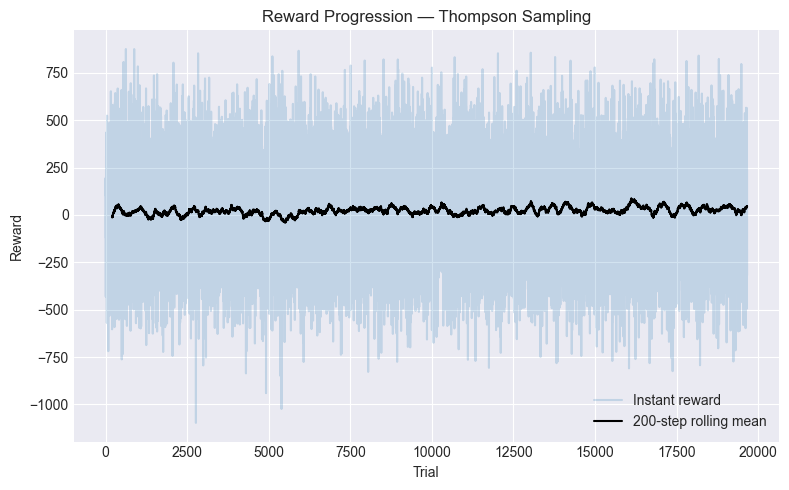

In [7]:
window = 200
rolling_reward = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(8, 5))
plt.plot(reward_history, alpha=0.2, label='Instant reward')
plt.plot(rolling_reward, color='black', label=f'{window}-step rolling mean')
plt.title('Reward Progression — Thompson Sampling')
plt.xlabel('Trial')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Average Reward Over Time

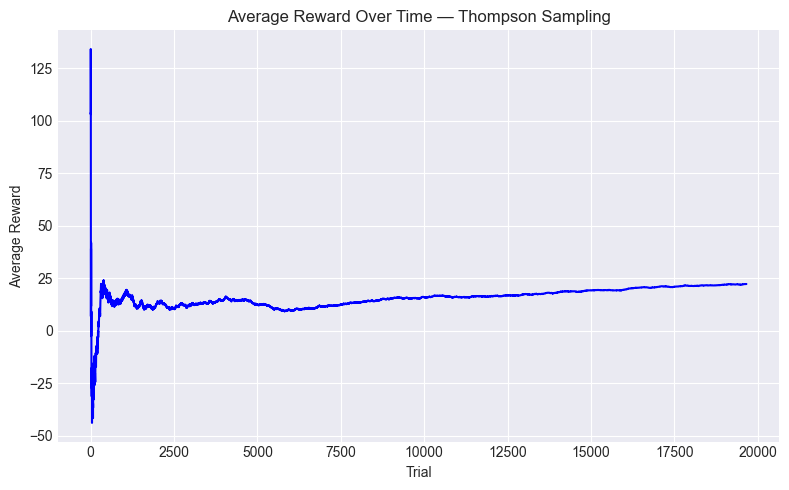

In [8]:
average_reward = np.cumsum(reward_history) / (np.arange(n_trials) + 1)

plt.figure(figsize=(8, 5))
plt.plot(average_reward, color='blue')
plt.title('Average Reward Over Time — Thompson Sampling')
plt.xlabel('Trial')
plt.ylabel('Average Reward')
plt.tight_layout()
plt.show()

### 5.3 Cumulative Regret

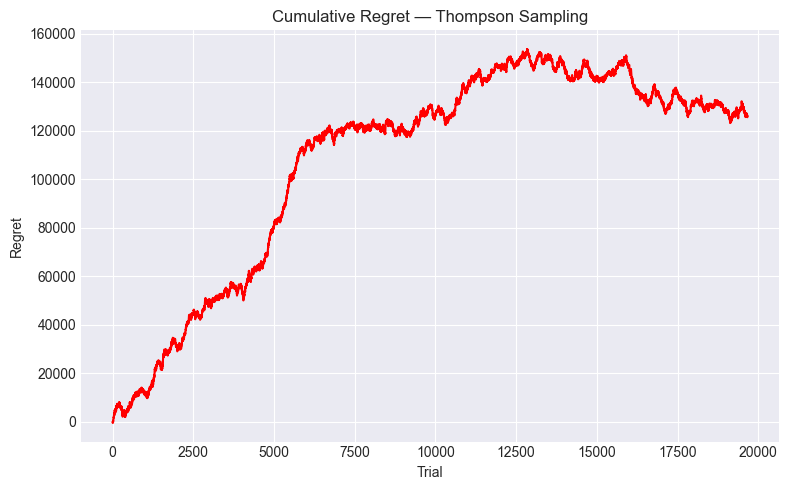

In [9]:
cumulative_regret = np.cumsum(regret_history)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_regret, color='red')
plt.title('Cumulative Regret — Thompson Sampling')
plt.xlabel('Trial')
plt.ylabel('Regret')
plt.tight_layout()
plt.show()

### 5.4 Arm Selection Counts

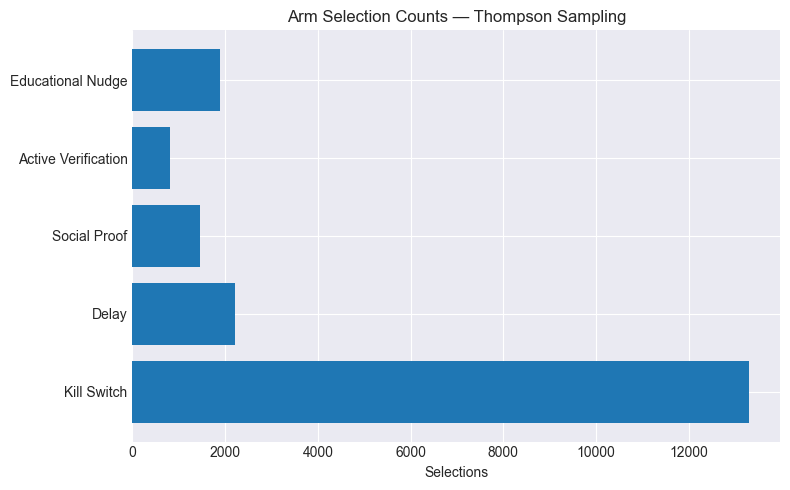

In [10]:
arm_counts = pd.Series(arm_history).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.barh(arm_names, arm_counts.values)
plt.title('Arm Selection Counts — Thompson Sampling')
plt.xlabel('Selections')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Final Posterior Summary

After all trials, the Beta posteriors show what Thompson Sampling learned about each arm's relative effectiveness.

In [11]:
print(f"{'Arm':<25} {'α':>8} {'β':>8} {'Mean θ':>10} {'Selections':>12}")
print("-" * 65)
for i, name in enumerate(arm_names):
    a = ts.alphas[i]
    b = ts.betas[i]
    mean_theta = a / (a + b)
    print(f"{name:<25} {a:>8.1f} {b:>8.1f} {mean_theta:>10.4f} {ts.counts[i]:>12}")

Arm                              α        β     Mean θ   Selections
-----------------------------------------------------------------
Educational Nudge            947.9    945.1     0.5007         1891
Active Verification          404.1    413.9     0.4940          816
Social Proof                 718.7    733.3     0.4950         1450
Delay                       1119.0   1091.0     0.5063         2208
Kill Switch                 7007.4   6294.6     0.5268        13300
